# F2 · Bridging an OEM deposit to customer prepayment

An equipment order requires a deposit before the customer’s prepayment becomes available. A **bridge loan** is short-term borrowing intended to cover that timing gap. The key questions are when the customer must pay and whether that receipt will repay the loan.

The project plans to purchase GPU equipment, unlike F1’s capacity reseller. **OEM** stands for original equipment manufacturer: the supplier taking the equipment order.

In this hypothetical example, the order costs USD 1,000,000 and requires a USD 200,000 deposit now. The equipment has not been delivered. Any lender protection at this stage depends on the actual contract and refund rights, rather than assuming delivered hardware is available to sell.

We borrow the deposit and must repay by day 60. The intended repayment source is a customer prepayment. Receiving it still leaves the project responsible for providing the future service.

Read [F1](F1_financing_a_compute_prepayment.ipynb) first. Allow 10–15 minutes; setup is in the [README](../README.md).

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from liquid_compute.bridge_financing import BridgeInputs, build_deposit_bridge_schedule
from liquid_compute.education import (
    explore_deposit_bridge,
    plot_bridge_cash,
    show_bridge_comparison,
)

order_cost_usd = 1_000_000
assumptions: BridgeInputs = dict(
    deposit_usd=200_000,
    draw_usd=200_000,
    prepayment_usd=250_000,
    nominal_annual_interest_rate=0.12,
    fee_fraction=0.01,
    condition_met=True,
    documentation_day=10,
    due_day=15,
    receipt_day=20,
    horizon_day=60,
    refund_day=None,
    refund_usd=0,
)
print(
    f"Remaining equipment price outside this bridge: USD {order_cost_usd - assumptions['deposit_usd']:,.0f}"
)

Remaining equipment price outside this bridge: USD 800,000


We will still need USD 800,000 for the rest of the equipment price. This lesson does not find that money. F5 looks at the later setup costs.

## Identify the condition that makes payment due

The customer’s obligation to pay begins only after the project provides evidence that the manufacturer accepted the order. Signing the customer agreement alone does not satisfy that condition.

Evidence of order acceptance is provided on day 10. The customer’s USD 250,000 prepayment becomes due on day 15 and is received on day 20.

The table distinguishes the condition being satisfied, the due date and the receipt date. Receipts and payments on the same day are netted together in this example.

In [3]:
from IPython.display import Markdown, display

display(
    Markdown("""| Event | Assumed day | Consequence |
|---|---:|---|
| Signed offtake | Before 0 | Conditional customer commitment |
| OEM deposit and bridge draw | 0 | USD 200,000 out and in; fee paid separately |
| Accepted order documented | 10 | Payment condition satisfied |
| Customer payment due | 15 | USD 250,000 owed; no cash yet |
| Customer cash settles | 20 | Repay bridge from receipt |
| Bridge maturity | 60 | Report any unpaid debt |""")
)

| Event | Assumed day | Consequence |
|---|---:|---|
| Signed offtake | Before 0 | Conditional customer commitment |
| OEM deposit and bridge draw | 0 | USD 200,000 out and in; fee paid separately |
| Accepted order documented | 10 | Payment condition satisfied |
| Customer payment due | 15 | USD 250,000 owed; no cash yet |
| Customer cash settles | 20 | Repay bridge from receipt |
| Bridge maturity | 60 | Report any unpaid debt |

The customer pays five days late. The payment was already owed. That is different from never meeting the rule that makes payment due.

## Count the cost of the wait

The lender charges 12% a year, spread over 365 days. This is **simple interest**: we charge it on borrowed principal, not on earlier interest.

For 20 days, the interest is USD 200,000 × 12% × 20/365.

There is also a 1% loan fee: USD 2,000 paid at the start. The fee is not added to the loan and earns no interest. These are our hypothetical loan terms, not rules for every loan.

In [4]:
interest_usd = 200_000 * 0.12 * 20 / 365
fee_usd = 200_000 * 0.01
payoff_usd = 200_000 + interest_usd
residual_customer_cash_usd = 250_000 - payoff_usd
print(f"20-day interest: USD {interest_usd:,.2f}")
print(f"Bridge payoff: USD {payoff_usd:,.2f}")
print(f"Customer cash remaining after payoff: USD {residual_customer_cash_usd:,.2f}")
print(f"Owner cash for day-0 fee: USD {fee_usd:,.2f}")

20-day interest: USD 1,315.07
Bridge payoff: USD 201,315.07
Customer cash remaining after payoff: USD 48,684.93
Owner cash for day-0 fee: USD 2,000.00


Twenty days of interest costs USD 1,315.07. We repay USD 201,315.07. From the customer's USD 250,000, that leaves USD 48,684.93.

We already paid the USD 2,000 fee. Including it leaves USD 46,684.93. This is leftover cash in this short example, not profit: we still owe the customer service.

## Track cash and outstanding debt separately

One schedule tracks cash received and paid; the other tracks principal and unpaid interest still owed. A missed repayment remains outstanding debt. The model does not assume an owner contributes cash to cover it.

The loan covers the deposit on day 0. We only need our own USD 2,000 for the fee at that point. The controls try different customer-payment days and amounts. They keep the fixed examples unchanged.

| Scenario | Customer status at horizon | Interest accrued (USD) | Unpaid debt (USD) | Initial cash buffer (USD) | Ending cash before owner funding (USD) |
|---|---|---:|---:|---:|---:|
| Baseline | received | 1,315.07 | 0.00 | 2,000.00 | 46,684.93 |

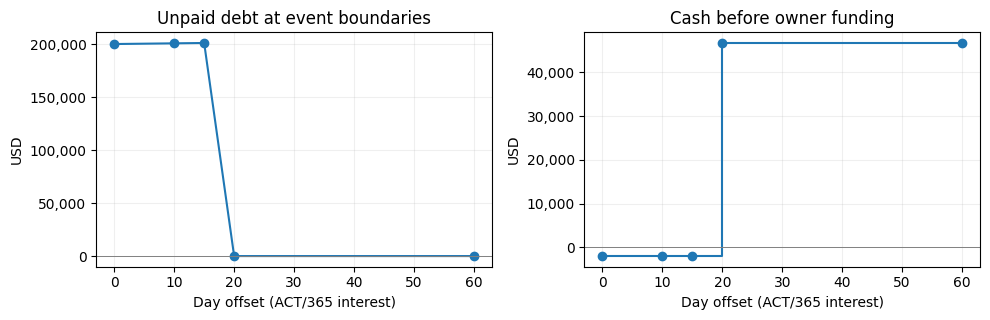

In [5]:
baseline = build_deposit_bridge_schedule(**assumptions)
show_bridge_comparison({"Baseline": baseline})
plot_bridge_cash(baseline)
explore_deposit_bridge(assumptions);

The customer money repays the loan on day 20. No debt remains on day 60. Our extra starting cash was only USD 2,000 because the loan covered the deposit.

That small cash need does not make repayment certain.

## Experiment 1 · Money arrives later

Keep the proof date at day 10 and the due date at day 15. Now let the money arrive on day 50.

The loan lasts longer. The fee stays the same. Interest keeps growing until repayment. In our example, we pay that interest when we repay the loan.

In [6]:
delayed_interest_usd = 200_000 * 0.12 * 50 / 365
print(f"Direct 50-day interest: USD {delayed_interest_usd:,.2f}")
delayed = build_deposit_bridge_schedule(**(assumptions | {"receipt_day": 50}))
show_bridge_comparison({"Baseline": baseline, "Late cash": delayed})

Direct 50-day interest: USD 3,287.67


| Scenario | Customer status at horizon | Interest accrued (USD) | Unpaid debt (USD) | Initial cash buffer (USD) | Ending cash before owner funding (USD) |
|---|---|---:|---:|---:|---:|
| Baseline | received | 1,315.07 | 0.00 | 2,000.00 | 46,684.93 |
| Late cash | received | 3,287.67 | 0.00 | 2,000.00 | 44,712.33 |

Waiting until day 50 raises interest to USD 3,287.67. Cash left after all these movements falls to USD 44,712.33. The starting fee and cash need stay USD 2,000.

The receipt still arrives before day 60 and pays the loan. We have not added late-payment penalties.

## Experiment 2 · The required proof never arrives

Now remove the proof, the payment due date, and the customer receipt. In the code, `None` means “this event does not happen.” It does not mean day zero.

The signed contract remains, but its payment rule is not met. In this case, no customer payment becomes due by day 60.

In [7]:
unmet_interest_usd = 200_000 * 0.12 * 60 / 365
print(f"Debt at day 60 without receipts: USD {200_000 + unmet_interest_usd:,.2f}")
unmet_inputs = assumptions | dict(
    condition_met=False, documentation_day=None, due_day=None, receipt_day=None
)
unmet = build_deposit_bridge_schedule(**unmet_inputs)
show_bridge_comparison({"Late cash": delayed, "Unmet condition": unmet})

Debt at day 60 without receipts: USD 203,945.21


| Scenario | Customer status at horizon | Interest accrued (USD) | Unpaid debt (USD) | Initial cash buffer (USD) | Ending cash before owner funding (USD) |
|---|---|---:|---:|---:|---:|
| Late cash | received | 3,287.67 | 0.00 | 2,000.00 | 44,712.33 |
| Unmet condition | conditional | 3,945.21 | 203,945.21 | 2,000.00 | -2,000.00 |

At day 60, USD 203,945.21 is still owed to the lender.

The cash schedule shows a USD 2,000 shortfall for the fee because no loan repayment has occurred. The USD 203,945.21 remains an outstanding obligation rather than a completed cash payment. A separate source of funding is still needed to repay it.

## Experiment 3 · Cancel and get part of the deposit back

Start with no customer payment. Suppose our contract allows a refund of 80% of the deposit, and it arrives on day 30.

This refund right is a hypothetical contract term, not an assumed manufacturer policy. We use the refund to repay borrowed principal first, then interest. Different loan rules could give a different answer.

In [8]:
refund_usd = 200_000 * 0.80
principal_after_refund_usd = 200_000 - refund_usd
interest_at_refund_usd = 200_000 * 0.12 * 30 / 365
further_interest_usd = principal_after_refund_usd * 0.12 * 30 / 365
print(f"Day-30 unpaid principal: USD {principal_after_refund_usd:,.2f}")
print(f"Day-30 unpaid interest: USD {interest_at_refund_usd:,.2f}")
print(f"Additional interest to day 60: USD {further_interest_usd:,.2f}")
refunded = build_deposit_bridge_schedule(
    **(unmet_inputs | dict(refund_day=30, refund_usd=refund_usd))
)
show_bridge_comparison({"No refund": unmet, "80% refund": refunded})

Day-30 unpaid principal: USD 40,000.00
Day-30 unpaid interest: USD 1,972.60
Additional interest to day 60: USD 394.52


| Scenario | Customer status at horizon | Interest accrued (USD) | Unpaid debt (USD) | Initial cash buffer (USD) | Ending cash before owner funding (USD) |
|---|---|---:|---:|---:|---:|
| No refund | conditional | 3,945.21 | 203,945.21 | 2,000.00 | -2,000.00 |
| 80% refund | conditional | 2,367.12 | 42,367.12 | 2,000.00 | -2,000.00 |

The USD 160,000 refund reduces principal to USD 40,000. At day 30, USD 1,972.60 interest is also owed.

Another USD 394.52 interest builds up on the remaining principal by day 60. We still owe **USD 42,367.12**. We do not charge interest on unpaid interest.

The refund helps, but it does not pay the whole debt. No refund money is left for the project.

## Look at cash and debt together

For each case, ask: Is the customer payment owed? When does it arrive? How much debt remains?

A lender needs a clear repayment source. A project needs money for fees and any debt left over. A customer who pays early still needs the promised service.

In [9]:
show_bridge_comparison(
    {
        "Day-20 receipt": baseline,
        "Day-50 receipt": delayed,
        "Condition unmet": unmet,
        "Cancellation/refund": refunded,
    }
)

| Scenario | Customer status at horizon | Interest accrued (USD) | Unpaid debt (USD) | Initial cash buffer (USD) | Ending cash before owner funding (USD) |
|---|---|---:|---:|---:|---:|
| Day-20 receipt | received | 1,315.07 | 0.00 | 2,000.00 | 46,684.93 |
| Day-50 receipt | received | 3,287.67 | 0.00 | 2,000.00 | 44,712.33 |
| Condition unmet | conditional | 3,945.21 | 203,945.21 | 2,000.00 | -2,000.00 |
| Cancellation/refund | conditional | 2,367.12 | 42,367.12 | 2,000.00 | -2,000.00 |

Late collection increases interest costs. An unmet payment condition can remove the intended repayment source altogether. A partial deposit refund reduces the exposure but may leave debt outstanding.

**Next: F3.** We examine customer contracts and the cash they can support. F5 later covers delivery and setup; the remaining equipment price is still unpaid here.

The [World Bank explains project funding stages](https://ppp.worldbank.org/financing/project-finance-concepts). It does not supply the manufacturer’s terms, refund rights or loan pricing. All these dates and amounts are hypothetical. See the [roadmap](README.md).